In [2]:
import psycopg2

conn = psycopg2.connect(
    host="127.0.0.1",
    dbname="postgres",
    user="postgres",
    password="672437002"
)

conn.autocommit = True
cur = conn.cursor()

# สร้าง database
cur.execute("CREATE DATABASE set_ptt;")

print("Database set_ptt created successfully!")

cur.close()
conn.close()

Database set_ptt created successfully!


In [4]:
import psycopg2

conn = psycopg2.connect(
    host="127.0.0.1",
    dbname="set_ptt",
    user="postgres",
    password="672437002"
)

print("Connected to set_ptt successfully!")

Connected to set_ptt successfully!


In [6]:
import psycopg2

conn = psycopg2.connect(
    host="127.0.0.1",
    dbname="postgres",
    user="postgres",
    password="672437002"
)

cur = conn.cursor()

cur.execute("SELECT datname FROM pg_database;")
databases = cur.fetchall()

print("List of databases:")
for db in databases:
    print("-", db[0])

cur.close()
conn.close()

List of databases:
- postgres
- template1
- template0
- set_ptt


In [8]:
import pandas as pd

df = pd.DataFrame(databases, columns=["Database Name"])
df

,Database Name
0,postgres
1,template1
2,template0
3,set_ptt


In [10]:
import psycopg2

conn = psycopg2.connect(
    host="127.0.0.1",
    dbname="postgres",
    user="postgres",
    password="672437002"
)

conn.autocommit = True
cur = conn.cursor()

print("Connected to PostgreSQL")

Connected to PostgreSQL


In [12]:
cur.execute("DROP DATABASE IF EXISTS financial_db;")
cur.execute("CREATE DATABASE financial_db;")

print("financial_db created successfully")

cur.close()
conn.close()

financial_db created successfully


In [14]:
conn = psycopg2.connect(
    host="127.0.0.1",
    dbname="financial_db",
    user="postgres",
    password="672437002"
)

cur = conn.cursor()

In [16]:
cur.execute("""
CREATE TABLE IF NOT EXISTS aapl_stock (
    trade_date DATE PRIMARY KEY,
    open NUMERIC,
    high NUMERIC,
    low NUMERIC,
    close NUMERIC,
    volume BIGINT
);
""")

conn.commit()
print("Table created successfully")

Table created successfully


In [18]:
cur.execute("""
INSERT INTO aapl_stock (trade_date, open, high, low, close, volume)
VALUES
('2024-01-02', 187.15, 188.44, 183.89, 185.64, 82488700),
('2024-01-03', 184.22, 185.88, 182.90, 183.25, 58414500),
('2024-01-04', 182.15, 183.55, 180.88, 181.91, 71983600)
ON CONFLICT (trade_date) DO NOTHING;
""")

conn.commit()
print("Sample data inserted")

Sample data inserted


In [20]:
cur.execute("SELECT * FROM aapl_stock;")
rows = cur.fetchall()

for row in rows:
    print(row)

(datetime.date(2024, 1, 2), Decimal('187.15'), Decimal('188.44'), Decimal('183.89'), Decimal('185.64'), 82488700)
(datetime.date(2024, 1, 3), Decimal('184.22'), Decimal('185.88'), Decimal('182.90'), Decimal('183.25'), 58414500)
(datetime.date(2024, 1, 4), Decimal('182.15'), Decimal('183.55'), Decimal('180.88'), Decimal('181.91'), 71983600)


In [24]:
!pip3 install yfinance

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [26]:
import yfinance as yf
import pandas as pd

# ดึงข้อมูลย้อนหลัง 1 ปี
aapl = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

aapl.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,


In [29]:
aapl.reset_index(inplace=True)

aapl = aapl[['Date','Open','High','Low','Close','Volume']]
aapl.columns = ['trade_date','open','high','low','close','volume']

aapl.head()

KeyError: "None of [Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')] are in the [columns]"

In [31]:
print(aapl.columns)

Index(['index', 'trade_date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')


In [33]:
aapl = aapl.drop(columns=['index'])
aapl.head()

,trade_date,open,high,low,close,volume


In [35]:
print(aapl.columns)

Index(['trade_date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')


In [37]:
for _, row in aapl.iterrows():
    cur.execute("""
        INSERT INTO aapl_stock (trade_date, open, high, low, close, volume)
        VALUES (%s, %s, %s, %s, %s, %s)
        ON CONFLICT (trade_date) DO NOTHING;
    """, (
        row['trade_date'],
        row['open'],
        row['high'],
        row['low'],
        row['close'],
        row['volume']
    ))

conn.commit()
print("AAPL data inserted successfully!")

AAPL data inserted successfully!


In [39]:
cur.execute("SELECT COUNT(*) FROM aapl_stock;")
print("Total rows:", cur.fetchone()[0])

Total rows: 3


In [41]:
cur.execute("TRUNCATE TABLE aapl_stock;")
conn.commit()

print("Table cleared")

Table cleared


In [43]:
print("Rows in DataFrame:", len(aapl))

Rows in DataFrame: 0


In [45]:
import yfinance as yf

aapl = yf.download("AAPL", period="1y")

print(aapl.head())
print("Rows:", len(aapl))

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Empty DataFrame
Columns: [(Adj Close, AAPL), (Close, AAPL), (High, AAPL), (Low, AAPL), (Open, AAPL), (Volume, AAPL)]
Index: []
Rows: 0


In [47]:
aapl = yf.Ticker("AAPL").history(period="1y")
print(aapl.head())
print("Rows:", len(aapl))

YFRateLimitError: Too Many Requests. Rate limited. Try after a while.

In [49]:
import pandas as pd
import time
import datetime as dt

# กำหนดช่วงเวลา
start = int(time.mktime(dt.datetime(2023,1,1).timetuple()))
end   = int(time.mktime(dt.datetime(2024,1,1).timetuple()))

url = f"https://query1.finance.yahoo.com/v7/finance/download/AAPL?period1={start}&period2={end}&interval=1d&events=history&includeAdjustedClose=true"

aapl = pd.read_csv(url)

print(aapl.head())
print("Rows:", len(aapl))

HTTPError: HTTP Error 429: Too Many Requests

In [51]:
import requests
import pandas as pd

API_KEY = "ใส่_api_key_ของหนูตรงนี้"

url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=AAPL&outputsize=full&apikey={API_KEY}"

r = requests.get(url)
data = r.json()

# แปลงเป็น DataFrame
df = pd.DataFrame.from_dict(data["Time Series (Daily)"], orient="index")

df.index = pd.to_datetime(df.index)
df = df.sort_index()

df.columns = ['open','high','low','close','volume']

df = df.astype(float)
df = df.reset_index()
df.rename(columns={'index':'trade_date'}, inplace=True)

print(df.head())
print("Rows:", len(df))

KeyError: 'Time Series (Daily)'

In [53]:
cur.execute("SELECT COUNT(*) FROM aapl_stock;")
print("Rows in DB:", cur.fetchone()[0])

Rows in DB: 0


In [55]:
print(len(df))
df.head()

4


,Database Name
0,postgres
1,template1
2,template0
3,set_ptt


In [57]:
import yfinance as yf
import pandas as pd

df = yf.download(
    "AAPL",
    period="10y",
    interval="1d",
    auto_adjust=True,
    progress=False
)

df = df.reset_index()

df.rename(columns={
    "Date": "trade_date",
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close": "close",
    "Volume": "volume"
}, inplace=True)

print("Rows downloaded:", len(df))
df.head()


1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Rows downloaded: 0


Price,trade_date,Adj Close,close,high,low,open,volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL


In [59]:
import pandas as pd

url = "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv"

df = pd.read_csv(url)

df = df[['Date','AAPL.Open','AAPL.High','AAPL.Low','AAPL.Close','AAPL.Volume']]
df.columns = ['trade_date','open','high','low','close','volume']

df['trade_date'] = pd.to_datetime(df['trade_date'])

print("Rows downloaded:", len(df))
df.head()

Rows downloaded: 506


,trade_date,open,high,low,close,volume
0,2015-02-17,127.489998,128.880005,126.919998,127.830002,63152400
1,2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700
2,2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400
3,2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400
4,2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100


In [61]:
for _, row in df.iterrows():
    cur.execute("""
        INSERT INTO aapl_stock (trade_date, open, high, low, close, volume)
        VALUES (%s, %s, %s, %s, %s, %s)
        ON CONFLICT (trade_date) DO NOTHING;
    """, (
        row['trade_date'],
        float(row['open']),
        float(row['high']),
        float(row['low']),
        float(row['close']),
        int(row['volume'])
    ))

conn.commit()
print("Insert complete!")

Insert complete!


In [63]:
cur.execute("SELECT COUNT(*) FROM aapl_stock;")
print("Rows in DB:", cur.fetchone()[0])

Rows in DB: 506


In [65]:
import pandas as pd

sql = "SELECT * FROM aapl_stock ORDER BY trade_date;"
df = pd.read_sql(sql, conn)

df.head()

/var/folders/s1/d92l8pcd3xj0465l248s42800000gp/T/ipykernel_82725/691878782.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


,trade_date,open,high,low,close,volume
0,2015-02-17,127.489998,128.880005,126.919998,127.830002,63152400
1,2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700
2,2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400
3,2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400
4,2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100


Matplotlib is building the font cache; this may take a moment.
/var/folders/s1/d92l8pcd3xj0465l248s42800000gp/T/ipykernel_82725/1845512217.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_plot = pd.read_sql(sql, conn)


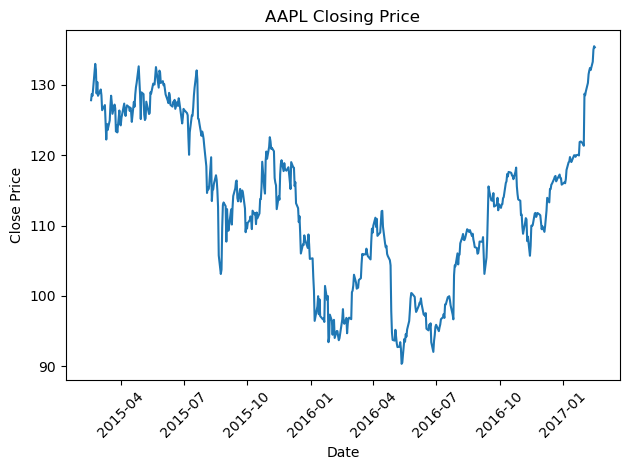

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

# ดึงข้อมูลจาก PostgreSQL
sql = "SELECT trade_date, close FROM aapl_stock ORDER BY trade_date;"
df_plot = pd.read_sql(sql, conn)

# แปลงเป็น datetime
df_plot['trade_date'] = pd.to_datetime(df_plot['trade_date'])

# สร้างกราฟ 1 กราฟ
plt.figure()
plt.plot(df_plot['trade_date'], df_plot['close'])
plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/s1/d92l8pcd3xj0465l248s42800000gp/T/ipykernel_82725/3202323287.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_plot = pd.read_sql(sql, conn)


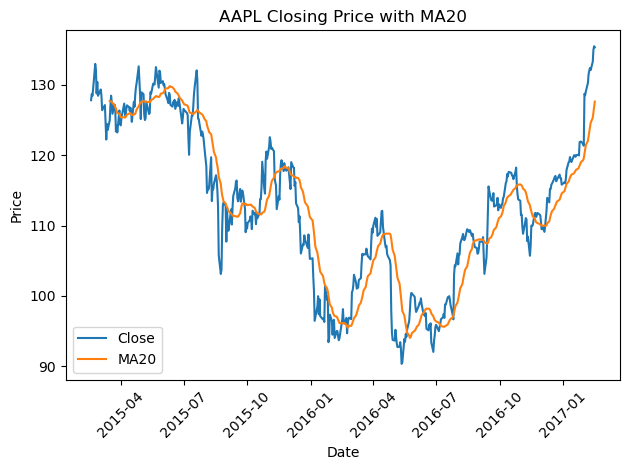

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

sql = "SELECT trade_date, close FROM aapl_stock ORDER BY trade_date;"
df_plot = pd.read_sql(sql, conn)

df_plot['trade_date'] = pd.to_datetime(df_plot['trade_date'])

# คำนวณ Moving Average 20 วัน
df_plot['MA20'] = df_plot['close'].rolling(window=20).mean()

plt.figure()
plt.plot(df_plot['trade_date'], df_plot['close'], label='Close')
plt.plot(df_plot['trade_date'], df_plot['MA20'], label='MA20')

plt.title("AAPL Closing Price with MA20")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
cur.close()
print("[INFO] Cursor closed.")

conn.close()
print("[INFO] Database connection closed.")

[INFO] Cursor closed.
[INFO] Database connection closed.
